# wave01 diagnostics

Random-init selfplay bootstrap (20k games, map2, sims=800). Goals:
1. cost/entropy/depth distributions and per-node breakdowns
2. sample interesting games (cheap, exploratory, outliers)
3. export selected games to atom-viz JSON

See `experiments/wave01_expectations.md` for target envelopes.

In [1]:
import os, sys, json, glob, torch, duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt

REPO = '/home/marko/grid_mcts2_prior_learning'
DATASET = f'{REPO}/data_selfplay/wave01'
MAP_DIR = next(iter(glob.glob(f'{DATASET}/games/*/*')))  # single map_class/map_id
EXPORT_DIR = f'{REPO}/data_selfplay/wave01_atomviz'
os.makedirs(EXPORT_DIR, exist_ok=True)

if REPO not in sys.path: sys.path.insert(0, REPO)
from neutral_atoms.config import get_config, set_derived_config, get_map_data, atom_map_to_positions
from neutral_atoms.game import Game
from neutral_atoms.experiment import game_to_solution, compute_solution_cost, log_game_trace

# load parquet index
paths = sorted(glob.glob(f'{DATASET}/index/*.parquet'))
con = duckdb.connect()
df = con.execute(f"SELECT * FROM read_parquet({paths!r})").fetchdf()
df['node'] = df['game_id'].str.split('_').str[0]
print(f'rows={len(df)}  map_class={df.map_class.iloc[0]}  sims={df.num_simulations.iloc[0]}  weight_gen={df.weight_gen.iloc[0]}')
df.head()

rows=20000  map_class=5x5_12qb_4gpl_3lyrs  sims=800  weight_gen=0


,game_id,map_class,map_id,cost,steps,num_moves,noop_frac,move_distance,policy_entropy,root_value,...,weight_git_sha,selfplay_git_sha,slurm_job_id,slurm_array_task_id,reward_mode,prior_mix_weight,batch_file,game_idx,timestamp,node
0,node0_000000_0000,5x5_12qb_4gpl_3lyrs,14c99a5d,30,24,22,0.083,71,2.232,-8.635,...,,72b43b63ae7250c8f926abcaa355b0065c0486b2,59387951,0,plan_cost,0.0,games/5x5_12qb_4gpl_3lyrs/14c99a5d/batch_node0...,0,2026-04-15 13:14:22,node0
1,node0_000000_0001,5x5_12qb_4gpl_3lyrs,14c99a5d,32,24,23,0.042,80,2.177,-6.752,...,,72b43b63ae7250c8f926abcaa355b0065c0486b2,59387951,0,plan_cost,0.0,games/5x5_12qb_4gpl_3lyrs/14c99a5d/batch_node0...,1,2026-04-15 13:14:22,node0
2,node0_000000_0002,5x5_12qb_4gpl_3lyrs,14c99a5d,28,24,21,0.125,69,2.232,-8.441,...,,72b43b63ae7250c8f926abcaa355b0065c0486b2,59387951,0,plan_cost,0.0,games/5x5_12qb_4gpl_3lyrs/14c99a5d/batch_node0...,2,2026-04-15 13:14:22,node0
3,node0_000000_0003,5x5_12qb_4gpl_3lyrs,14c99a5d,29,24,21,0.125,63,2.263,-8.813,...,,72b43b63ae7250c8f926abcaa355b0065c0486b2,59387951,0,plan_cost,0.0,games/5x5_12qb_4gpl_3lyrs/14c99a5d/batch_node0...,3,2026-04-15 13:14:22,node0
4,node0_000000_0004,5x5_12qb_4gpl_3lyrs,14c99a5d,30,24,19,0.208,67,2.279,-8.115,...,,72b43b63ae7250c8f926abcaa355b0065c0486b2,59387951,0,plan_cost,0.0,games/5x5_12qb_4gpl_3lyrs/14c99a5d/batch_node0...,4,2026-04-15 13:14:22,node0


## 1. Summary stats

Compare against expectations table. Wave01 = random init, so expect `mean>24`, low `mcts_depth`, flat entropy.

In [2]:
# map-level constants
c = get_config(); c.map_num = 2; set_derived_config(c)
m = get_map_data(c)
from neutral_atoms.env import NeutralAtomsEnv
env = NeutralAtomsEnv(m['tasks'], atom_map_to_positions(m['atom_map'], c.env.board_width), c.env)
env.reset()
SMT_BOUND = 11
DO_NOTHING = env.cost_ub
EPISODE_LEN = sum(len({q for p in L for q in p}) for L in m['tasks'])
print(f'SMT={SMT_BOUND}  do_nothing={DO_NOTHING}  episode_len={EPISODE_LEN}  branching={c.network.num_actions}')

cols = ['cost','policy_entropy','mcts_depth','mcts_reward_frac','mcts_boundary_frac',
        'noop_frac','move_distance','num_moves','root_value','game_time_s']
summary = df[cols].describe().T[['mean','std','min','50%','max']].round(2)
summary.insert(0, 'target_min', ['', 0.5, 6, 0.3, 0.4, '', '', '', '', ''])
summary

SMT=11  do_nothing=24  episode_len=24  branching=25


,target_min,mean,std,min,50%,max
cost,,32.42,2.96,21.00,32.00,44.00
policy_entropy,0.5,2.24,0.05,2.00,2.24,2.40
mcts_depth,6,3.17,0.06,3.00,3.20,3.50
mcts_reward_frac,0.3,0.84,0.03,0.72,0.85,0.94
mcts_boundary_frac,0.4,0.46,0.02,0.41,0.46,0.53
noop_frac,,0.09,0.06,0.00,0.08,0.38
move_distance,,69.50,8.57,38.00,69.00,105.00
num_moves,,21.77,1.43,15.00,22.00,24.00
root_value,,-8.19,0.49,-10.00,-8.19,-6.22
game_time_s,,55.28,1.19,51.95,55.15,72.07


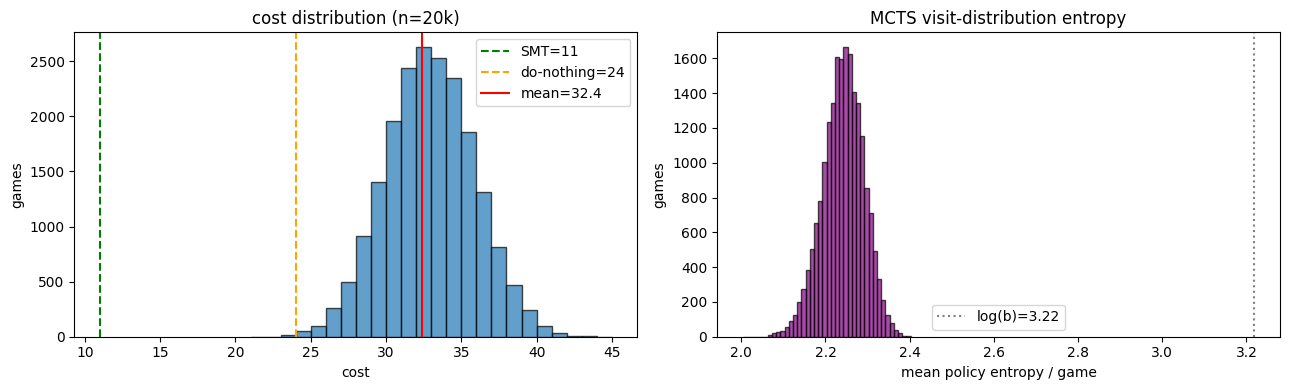

In [3]:
# cost histogram with SMT + do-nothing markers
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].hist(df.cost, bins=range(int(df.cost.min()), int(df.cost.max())+2), edgecolor='k', alpha=0.7)
ax[0].axvline(SMT_BOUND, color='green', ls='--', label=f'SMT={SMT_BOUND}')
ax[0].axvline(DO_NOTHING, color='orange', ls='--', label=f'do-nothing={DO_NOTHING}')
ax[0].axvline(df.cost.mean(), color='red', label=f'mean={df.cost.mean():.1f}')
ax[0].set_xlabel('cost'); ax[0].set_ylabel('games'); ax[0].legend(); ax[0].set_title('cost distribution (n=20k)')

ax[1].hist(df.policy_entropy, bins=40, edgecolor='k', alpha=0.7, color='purple')
ax[1].axvline(np.log(c.network.num_actions), color='gray', ls=':', label=f'log(b)={np.log(c.network.num_actions):.2f}')
ax[1].set_xlabel('mean policy entropy / game'); ax[1].set_ylabel('games'); ax[1].legend()
ax[1].set_title('MCTS visit-distribution entropy')
plt.tight_layout(); plt.show()

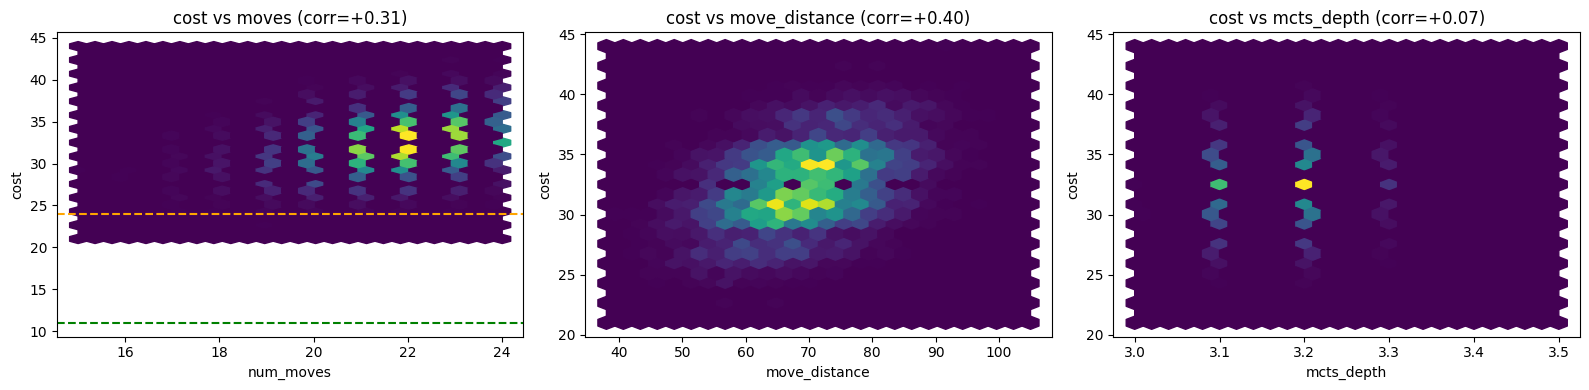

In [4]:
# joint: cost vs. move_distance + noop_frac (intuitive: more moves -> worse)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hexbin(df.num_moves, df.cost, gridsize=25, cmap='viridis'); ax[0].set_xlabel('num_moves'); ax[0].set_ylabel('cost')
ax[0].axhline(SMT_BOUND, color='g', ls='--'); ax[0].axhline(DO_NOTHING, color='orange', ls='--')
ax[0].set_title(f'cost vs moves (corr={df.cost.corr(df.num_moves):+.2f})')
ax[1].hexbin(df.move_distance, df.cost, gridsize=25, cmap='viridis'); ax[1].set_xlabel('move_distance'); ax[1].set_ylabel('cost')
ax[1].set_title(f'cost vs move_distance (corr={df.cost.corr(df.move_distance):+.2f})')
ax[2].hexbin(df.mcts_depth, df.cost, gridsize=25, cmap='viridis'); ax[2].set_xlabel('mcts_depth'); ax[2].set_ylabel('cost')
ax[2].set_title(f'cost vs mcts_depth (corr={df.cost.corr(df.mcts_depth):+.2f})')
plt.tight_layout(); plt.show()

## 2. Per-node breakdown

20 nodes ran independently on same map + seeds — any skew indicates infra bug. Expect tight clustering.

           n    mean    std  best  depth    ent     game_t
node                                                      
node15  1000  32.233  3.082    23  3.176  2.230  55.433998
node11  1000  32.275  3.031    23  3.168  2.234  54.299999
node0   1000  32.286  2.835    21  3.168  2.250  54.098000
node19  1000  32.311  2.816    23  3.156  2.244  56.403000
node6   1000  32.319  2.956    24  3.157  2.239  57.715000
node8   1000  32.348  2.959    25  3.242  2.232  54.062000
node13  1000  32.386  2.989    24  3.170  2.236  54.551998
node14  1000  32.389  2.919    24  3.187  2.248  55.485001
node2   1000  32.398  2.823    24  3.157  2.244  54.104000
node5   1000  32.403  2.989    23  3.158  2.254  55.744999
node17  1000  32.439  2.931    25  3.163  2.246  57.195999
node1   1000  32.455  3.085    24  3.142  2.243  54.837002
node7   1000  32.468  2.952    22  3.169  2.247  55.043999
node16  1000  32.472  2.955    24  3.154  2.241  55.292000
node3   1000  32.501  2.876    24  3.180  2.250  55.3499

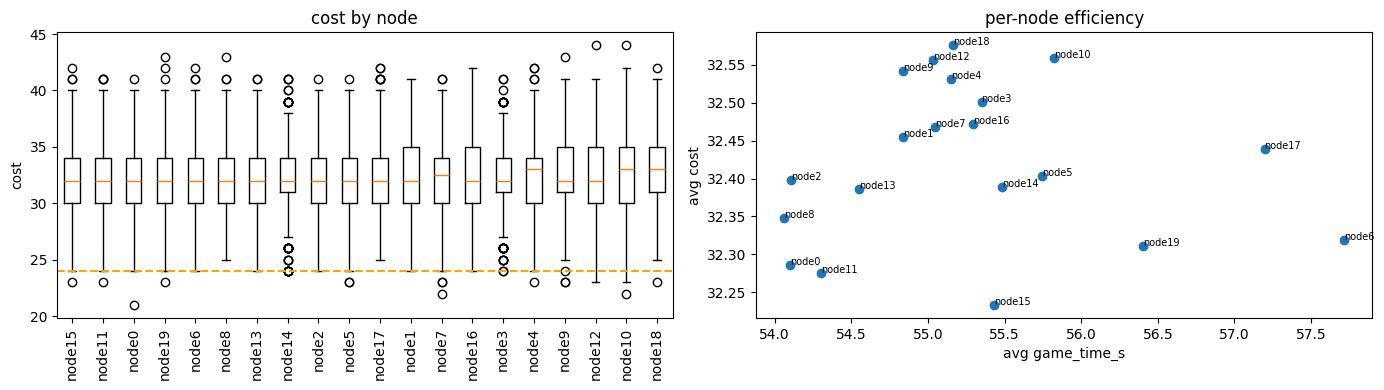

In [5]:
g = df.groupby('node').agg(n=('cost','size'), mean=('cost','mean'), std=('cost','std'),
                            best=('cost','min'), depth=('mcts_depth','mean'),
                            ent=('policy_entropy','mean'), game_t=('game_time_s','mean'))
g = g.sort_values('mean').round(3); print(g.to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
order = g.index.tolist()
parts = [df[df.node==n].cost.values for n in order]
ax[0].boxplot(parts, tick_labels=order); ax[0].set_ylabel('cost'); ax[0].tick_params(axis='x', rotation=90)
ax[0].axhline(DO_NOTHING, color='orange', ls='--'); ax[0].set_title('cost by node')
ax[1].scatter(g.game_t, g['mean']); ax[1].set_xlabel('avg game_time_s'); ax[1].set_ylabel('avg cost')
for n,r in g.iterrows(): ax[1].annotate(n, (r.game_t, r['mean']), fontsize=7)
ax[1].set_title('per-node efficiency')
plt.tight_layout(); plt.show()

## 3. Sample interesting games

Pick:
- **A. cheapest** (good bootstrap examples)
- **B. highest-entropy low-cost** (diverse good games)
- **C. depth outliers** (where random priors accidentally deepened search)
- **D. worst** (stress-test viz on failure modes)

In [6]:
picks = {}
picks['cheapest'] = df.nsmallest(3, 'cost')
picks['diverse_good'] = df[df.cost <= df.cost.quantile(0.01)].nlargest(3, 'policy_entropy')
picks['deep_search'] = df.nlargest(3, 'mcts_depth')
picks['worst'] = df.nlargest(2, 'cost')
for tag, sub in picks.items():
    print(f'== {tag} ==')
    print(sub[['game_id','cost','policy_entropy','mcts_depth','noop_frac','move_distance','batch_file']].to_string(index=False))
    print()

== cheapest ==
           game_id  cost  policy_entropy  mcts_depth  noop_frac  move_distance                                                batch_file
 node0_000002_0055    21           2.294         3.1      0.125             57  games/5x5_12qb_4gpl_3lyrs/14c99a5d/batch_node0_000002.pt
node10_000005_0030    22           2.210         3.2      0.167             70 games/5x5_12qb_4gpl_3lyrs/14c99a5d/batch_node10_000005.pt
 node7_000014_0031    22           2.215         3.2      0.208             49  games/5x5_12qb_4gpl_3lyrs/14c99a5d/batch_node7_000014.pt

== diverse_good ==
          game_id  cost  policy_entropy  mcts_depth  noop_frac  move_distance                                               batch_file
node6_000005_0020    26           2.373         3.1      0.208             57 games/5x5_12qb_4gpl_3lyrs/14c99a5d/batch_node6_000005.pt
node4_000005_0017    26           2.360         3.1      0.292             43 games/5x5_12qb_4gpl_3lyrs/14c99a5d/batch_node4_000005.pt
node6_000014

In [7]:
# helper: load one game_dict by (batch_file, game_idx)
def load_game_dict(batch_file_rel, game_idx):
    path = f'{DATASET}/{batch_file_rel}'
    return torch.load(path, weights_only=False)[int(game_idx)]

def game_from_dict(gd):
    # reconstruct minimal Game object for game_to_solution (needs env_config)
    # env_config comes from the shared config for this map
    return Game.from_dict(gd, c.env)

def export_atomviz(row, out_name=None):
    gd = load_game_dict(row.batch_file, row.game_idx)
    g = game_from_dict(gd)
    sol = game_to_solution(g)
    cost_replay = compute_solution_cost(g)
    assert cost_replay == gd['cost'], f'replay mismatch {cost_replay} vs {gd["cost"]}'
    name = out_name or f"{row.game_id}_c{row.cost}"
    with open(f'{EXPORT_DIR}/{name}.json', 'w') as f:
        json.dump(sol, f, indent=2)
    return f'{EXPORT_DIR}/{name}.json', sol

# sanity-check one game end-to-end
row = picks['cheapest'].iloc[0]
path, sol = export_atomviz(row, f'cheapest_{row.game_id}')
print(f'wrote {path}')
print(f'circuit layers: {len(sol["circuit"])}  moves/layer: {[len(p) for p in sol["plan"]]}')

wrote /home/marko/grid_mcts2_prior_learning/data_selfplay/wave01_atomviz/cheapest_node0_000002_0055.json
circuit layers: 3  moves/layer: [7, 6, 8]


In [8]:
# export full sample pool to atom-viz
exported = []
for tag, sub in picks.items():
    for _, row in sub.iterrows():
        path, _ = export_atomviz(row, f'{tag}_{row.game_id}_c{row.cost}')
        exported.append((tag, row.game_id, row.cost, path))
print(f'exported {len(exported)} games -> {EXPORT_DIR}')
pd.DataFrame(exported, columns=['tag','game_id','cost','path'])

exported 11 games -> /home/marko/grid_mcts2_prior_learning/data_selfplay/wave01_atomviz


,tag,game_id,cost,path
0,cheapest,node0_000002_0055,21,/home/marko/grid_mcts2_prior_learning/data_sel...
1,cheapest,node10_000005_0030,22,/home/marko/grid_mcts2_prior_learning/data_sel...
2,cheapest,node7_000014_0031,22,/home/marko/grid_mcts2_prior_learning/data_sel...
3,diverse_good,node6_000005_0020,26,/home/marko/grid_mcts2_prior_learning/data_sel...
4,diverse_good,node4_000005_0017,26,/home/marko/grid_mcts2_prior_learning/data_sel...
5,diverse_good,node6_000014_0003,26,/home/marko/grid_mcts2_prior_learning/data_sel...
6,deep_search,node8_000011_0046,36,/home/marko/grid_mcts2_prior_learning/data_sel...
7,deep_search,node1_000006_0057,33,/home/marko/grid_mcts2_prior_learning/data_sel...
8,deep_search,node10_000004_0057,31,/home/marko/grid_mcts2_prior_learning/data_sel...
9,worst,node10_000002_0001,44,/home/marko/grid_mcts2_prior_learning/data_sel...


## 4. Per-game traces (optional)

Full step-by-step trace (action type / qubit / cost_before / cost_after / reward) — useful for debugging when atom-viz animation looks wrong.

In [9]:
row = picks['cheapest'].iloc[0]
gd = load_game_dict(row.batch_file, row.game_idx)
g = game_from_dict(gd)
os.makedirs(f'{EXPORT_DIR}/solutions', exist_ok=True)
trace = log_game_trace(g, EXPORT_DIR, label=f'trace_{row.game_id}')
print(f'trace len={len(trace)}, reward sum={sum(t["reward"] for t in trace):.2f}, cost={gd["cost"]}')
trace[:6]

trace len=24, reward sum=-3.00, cost=21


[{'step': 0,
  'action': 6,
  'qubit': 3,
  'layer': 0,
  'action_type': 'move',
  'src': [2, 1],
  'dst': [1, 1],
  'cost_before': 18,
  'cost_after': 19,
  'reward': -1.0,
  'tasks_done': 0},
 {'step': 1,
  'action': 1,
  'qubit': 4,
  'layer': 0,
  'action_type': 'move',
  'src': [3, 0],
  'dst': [0, 1],
  'cost_before': 19,
  'cost_after': 18,
  'reward': -1.0,
  'tasks_done': 0},
 {'step': 2,
  'action': 14,
  'qubit': 6,
  'layer': 0,
  'action_type': 'move',
  'src': [0, 2],
  'dst': [2, 4],
  'cost_before': 18,
  'cost_after': 21,
  'reward': -1.0,
  'tasks_done': 0},
 {'step': 3,
  'action': 16,
  'qubit': 7,
  'layer': 0,
  'action_type': 'move',
  'src': [4, 1],
  'dst': [3, 1],
  'cost_before': 21,
  'cost_after': 19,
  'reward': 0.0,
  'tasks_done': 0},
 {'step': 4,
  'action': 19,
  'qubit': 8,
  'layer': 0,
  'action_type': 'move',
  'src': [4, 2],
  'dst': [3, 4],
  'cost_before': 19,
  'cost_after': 19,
  'reward': 2.0,
  'tasks_done': 0},
 {'step': 5,
  'action': 23,


## 5. Wave-over-wave comparison (stub)

When wave02+ arrives (trained weights), this cell compares distributions across `weight_gen` buckets.

In [10]:
all_waves = sorted(glob.glob(f'{REPO}/data_selfplay/wave*/index/*.parquet'))
if len({p.split("data_selfplay/")[1].split("/")[0] for p in all_waves}) <= 1:
    print('only wave01 present; run future waves then re-execute')
else:
    con = duckdb.connect(); dfa = con.execute(f"SELECT *, regexp_extract(filename, 'wave[0-9]+') AS wave FROM read_parquet({all_waves!r}, filename=true)").fetchdf()
    print(dfa.groupby('wave').agg(n=('cost','size'), avg=('cost','mean'), best=('cost','min'), ent=('policy_entropy','mean')).round(2))

only wave01 present; run future waves then re-execute
